# ⚽ Kulüplere Göre Transfer Pattern Analizi

**Transfermarkt Veri Seti | Ek Çalışma**



---

## Araştırma Sorusu

> **"Kulüpler transfer stratejilerine göre nasıl gruplandırılabilir? Hangi kulüpler benzer transfer pattern'leri gösteriyor?"**

## Kullanılan Yöntemler
- **KMeans Kümeleme:** Kulüpleri transfer özelliklerine göre otomatik gruplama
- **PCA (Temel Bileşen Analizi):** Çok boyutlu veriyi 2D'ye indirgeyerek görselleştirme
- **Elbow Method:** Optimal küme sayısının belirlenmesi

## Kullanılan Tablolar
- `transfers.csv` — Oyuncu transfer kayıtları
- `players.csv` — Oyuncu profilleri ve milliyet bilgileri
- `clubs.csv` — Kulüp detayları ve lig bilgileri

---

## 1. Kütüphaneler ve Veri Yükleme

In [12]:
# Kutuphaneler
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
print("Kütüphaneler yüklendi! ✅")

Kütüphaneler yüklendi! ✅


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Verileri yukle
# Not: Dosyalari Colab'a yukleyin veya Google Drive'dan baglayın
transfers = pd.read_csv('/content/drive/MyDrive/TransferMarkt-Football/transfers.csv')
players = pd.read_csv('/content/drive/MyDrive/TransferMarkt-Football/players.csv')
clubs = pd.read_csv('/content/drive/MyDrive/TransferMarkt-Football/clubs.csv')

print(f"✅ Transfers: {transfers.shape[0]:,} satır x {transfers.shape[1]} sütun")
print(f"✅ Players:   {players.shape[0]:,} satır x {players.shape[1]} sütun")
print(f"✅ Clubs:     {clubs.shape[0]:,} satır x {clubs.shape[1]} sütun")

✅ Transfers: 99,692 satır x 10 sütun
✅ Players:   37,579 satır x 26 sütun
✅ Clubs:     451 satır x 17 sütun


## 2. Veri Hazırlama ve Özellik Çıkarma

Transfer verilerini oyuncu bilgileriyle birleştirip analiz için gerekli özellikleri oluşturuyoruz.

### 2.1 Tarih Dönüşümleri ve Yaş Hesaplama

In [15]:
# Tarihleri datetime formatina cevir
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'], errors='coerce')
transfers['transfer_date'] = pd.to_datetime(transfers['transfer_date'], errors='coerce')

# Oyuncu bilgilerini transfer tablosuna ekle
transfers = transfers.merge(
    players[['player_id', 'date_of_birth', 'country_of_citizenship']],
    on='player_id', how='left'
)

# Transfer anindaki yas
transfers['age_at_transfer'] = (
    (transfers['transfer_date'] - transfers['date_of_birth']).dt.days // 365
)

print(f"Yaş hesaplanan transfer sayısı: {transfers['age_at_transfer'].notna().sum():,}")
print(f"Yaş aralığı: {transfers['age_at_transfer'].min():.0f} - {transfers['age_at_transfer'].max():.0f}")

Yaş hesaplanan transfer sayısı: 99,665
Yaş aralığı: 4 - 43


### 2.2 Kulüp Bilgileri ve Yabancı Oyuncu Tespiti

> **Düzeltme:** Yabancı oyuncu tespiti için oyuncunun vatandaşlığı ile kulübün bulunduğu ülkenin ligi karşılaştırılıyor. Ülke-lig eşleştirmesi kullanılarak doğru bir yabancı oyuncu oranı hesaplanıyor.

In [16]:
# Sadece lig bilgisini ekle (to_club_name zaten var, dokunmuyoruz)
clubs_league = clubs[['club_id', 'domestic_competition_id']].copy()
clubs_league = clubs_league.rename(columns={'club_id': 'to_club_id'})

# Eger onceki denemelerden club_league varsa temizle
if 'club_league' in transfers.columns:
    transfers = transfers.drop(columns=['club_league'])
if 'domestic_competition_id' in transfers.columns:
    transfers = transfers.drop(columns=['domestic_competition_id'])

transfers = transfers.merge(clubs_league, on='to_club_id', how='left')
transfers = transfers.rename(columns={'domestic_competition_id': 'club_league'})

# Lig-ulke eslestirmesi
league_country = {
    'GB1': 'England', 'ES1': 'Spain', 'IT1': 'Italy', 'L1': 'Germany',
    'FR1': 'France', 'TR1': 'Turkey', 'NL1': 'Netherlands', 'PO1': 'Portugal',
    'BE1': 'Belgium', 'RU1': 'Russia', 'GR1': 'Greece', 'SC1': 'Scotland',
    'UKR1': 'Ukraine', 'DK1': 'Denmark'
}
transfers['club_country'] = transfers['club_league'].map(league_country)

# Yabanci oyuncu tespiti
transfers['is_foreign'] = np.where(
    transfers['country_of_citizenship'] != transfers['club_country'], 1, 0
)
transfers['is_foreign'] = transfers['is_foreign'].fillna(0)

print(f"Toplam transfer: {len(transfers):,}")
print(f"Yabancı oyuncu oranı: {transfers['is_foreign'].mean()*100:.1f}%")
print(f"to_club_name dolu: {transfers['to_club_name'].notna().sum():,}")

Toplam transfer: 99,692
Yabancı oyuncu oranı: 80.6%
to_club_name dolu: 99,692


## 3. Kulüp Bazlı Özet Tablo

Her kulüp için transfer pattern özelliklerini hesaplıyoruz:
- **transfer_count:** Toplam transfer sayısı
- **avg_age:** Ortalama transfer yaşı
- **avg_transfer_fee:** Ortalama transfer ücreti
- **avg_market_value:** Ortalama piyasa değeri
- **foreign_ratio:** Yabancı oyuncu oranı

In [17]:
# Kulup bazinda ozet
club_summary = transfers.groupby('to_club_name').agg(
    transfer_count=('player_id', 'count'),
    avg_age=('age_at_transfer', 'mean'),
    avg_transfer_fee=('transfer_fee', 'mean'),
    avg_market_value=('market_value_in_eur', 'mean'),
    foreign_ratio=('is_foreign', 'mean')
).reset_index()

# NaN doldurma
club_summary.fillna(0, inplace=True)

# Cok az transferi olan kulupleri filtrele (gurultu azaltma)
min_transfers = 10
club_summary = club_summary[club_summary['transfer_count'] >= min_transfers].reset_index(drop=True)

print(f"Minimum {min_transfers} transfer yapan kulüp sayısı: {len(club_summary):,}")
print(f"\nÖzet İstatistikler:")
print(club_summary.describe().round(2))

Minimum 10 transfer yapan kulüp sayısı: 1,925

Özet İstatistikler:
       transfer_count  avg_age  avg_transfer_fee  avg_market_value  \
count         1925.00  1925.00           1925.00           1925.00   
mean            42.75    20.05         390768.87         899882.01   
std             62.14     3.43        1367139.34        1872497.41   
min             10.00     9.00              0.00              0.00   
25%             14.00    17.42              0.00          85000.00   
50%             24.00    20.76           2686.27         321428.57   
75%             47.00    22.59         146166.67         814285.71   
max           1970.00    34.76       19693750.00       18996946.56   

       foreign_ratio  
count        1925.00  
mean            0.88  
std             0.24  
min             0.00  
25%             1.00  
50%             1.00  
75%             1.00  
max             1.00  


## 4. Özellik Ölçekleme ve Optimal Küme Sayısı

### 4.1 StandardScaler ile Ölçekleme
KMeans mesafe tabanlı bir algoritma olduğu için tüm özellikleri aynı ölçeğe getirmemiz gerekiyor.

In [18]:
# Ozellik olcekleme
features = ['transfer_count', 'avg_age', 'avg_transfer_fee', 'avg_market_value', 'foreign_ratio']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(club_summary[features])

print("Ölçeklenmiş veri boyutu:", X_scaled.shape)
print("\nÖlçeklenmiş veri örneği:")
display(pd.DataFrame(X_scaled, columns=features).head())

Ölçeklenmiş veri boyutu: (1925, 5)

Ölçeklenmiş veri örneği:


,transfer_count,avg_age,avg_transfer_fee,avg_market_value,foreign_ratio
0,-0.511085,-1.076698,-0.285904,-0.480703,0.508344
1,0.004039,0.724901,-0.102764,0.069576,0.508344
2,1.307946,0.655859,0.566047,0.691924,-1.830497
3,-0.301816,-0.404364,-0.249322,-0.371641,0.508344
4,-0.189132,-1.418287,-0.285904,-0.480703,0.508344


### 4.2 Elbow Method ile Küme Sayısı Seçimi

Optimal küme sayısını belirlemek için Elbow Method kullanıyoruz. Inertia (toplam hata) değerinin keskin düşüşünün durduğu nokta optimal küme sayısını verir.

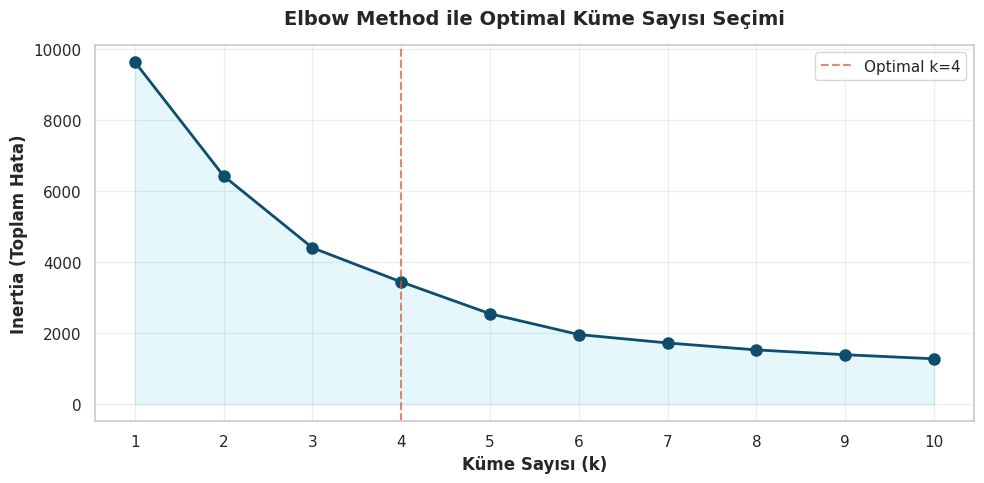

Inertia değerleri:
  k=1: 9625.00
  k=2: 6418.62
  k=3: 4397.31
  k=4: 3436.71
  k=5: 2542.38
  k=6: 1957.51
  k=7: 1720.82
  k=8: 1525.23
  k=9: 1389.73
  k=10: 1275.78


In [19]:
# Elbow Method
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Grafik
plt.figure(figsize=(10, 5))
plt.plot(K, inertia, marker='o', color='#0E4D6E', lw=2, markersize=8)
plt.fill_between(K, inertia, alpha=0.1, color='#00B4D8')
plt.xlabel('Küme Sayısı (k)', fontsize=12, fontweight='bold')
plt.ylabel('Inertia (Toplam Hata)', fontsize=12, fontweight='bold')
plt.title('Elbow Method ile Optimal Küme Sayısı Seçimi', fontsize=14, fontweight='bold', pad=15)
plt.xticks(K)
plt.grid(True, alpha=0.3)

# Optimal noktayi isaretle
plt.axvline(x=4, color='#D85A30', linestyle='--', alpha=0.7, label='Optimal k=4')
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Inertia değerleri:")
for k, i in zip(K, inertia):
    print(f"  k={k}: {i:.2f}")

## 5. KMeans Kümeleme

Elbow Method sonucuna göre **k=4** küme ile KMeans algoritmasını çalıştırıyoruz.

In [20]:
# KMeans kumeleme
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
club_summary['cluster'] = kmeans.fit_predict(X_scaled)

print("Küme Dağılımı:")
print(club_summary['cluster'].value_counts().sort_index())
print(f"\nToplam kulüp: {len(club_summary)}")

Küme Dağılımı:
cluster
0    702
1    388
2    775
3     60
Name: count, dtype: int64

Toplam kulüp: 1925


### 5.1 Küme Profilleri ve Yorumlama

Her kümenin ortalama özelliklerini inceleyerek transfer stratejilerini yorumlayalım.

In [21]:
# Kume bazinda ortalamalar
cluster_profiles = club_summary.groupby('cluster')[features].mean().round(2)

# Kume isimlerini belirle
print("=" * 70)
print("  KÜME PROFİLLERİ")
print("=" * 70)

for cluster_id in sorted(club_summary['cluster'].unique()):
    profile = cluster_profiles.loc[cluster_id]
    count = (club_summary['cluster'] == cluster_id).sum()
    print(f"\n--- Küme {cluster_id} ({count} kulüp) ---")
    print(f"  Transfer sayısı (ort.):     {profile['transfer_count']:.0f}")
    print(f"  Ortalama yaş:               {profile['avg_age']:.1f}")
    print(f"  Ort. transfer ücreti:       €{profile['avg_transfer_fee']:,.0f}")
    print(f"  Ort. piyasa değeri:         €{profile['avg_market_value']:,.0f}")
    print(f"  Yabancı oyuncu oranı:       {profile['foreign_ratio']*100:.1f}%")

# Gorsel tablo
print("\n" + "=" * 70)
print("\n📊 Küme Profilleri Tablosu:")
display(cluster_profiles)

  KÜME PROFİLLERİ

--- Küme 0 (702 kulüp) ---
  Transfer sayısı (ort.):     26
  Ortalama yaş:               16.3
  Ort. transfer ücreti:       €46,101
  Ort. piyasa değeri:         €111,771
  Yabancı oyuncu oranı:       100.0%

--- Küme 1 (388 kulüp) ---
  Transfer sayısı (ort.):     84
  Ortalama yaş:               22.9
  Ort. transfer ücreti:       €573,031
  Ort. piyasa değeri:         €1,524,590
  Yabancı oyuncu oranı:       46.0%

--- Küme 2 (775 kulüp) ---
  Transfer sayısı (ort.):     27
  Ortalama yaş:               21.8
  Ort. transfer ücreti:       €139,126
  Ort. piyasa değeri:         €650,822
  Yabancı oyuncu oranı:       99.0%

--- Küme 3 (60 kulüp) ---
  Transfer sayısı (ort.):     177
  Ortalama yaş:               23.4
  Ort. transfer ücreti:       €6,495,138
  Ort. piyasa değeri:         €9,298,029
  Yabancı oyuncu oranı:       70.0%


📊 Küme Profilleri Tablosu:


,transfer_count,avg_age,avg_transfer_fee,avg_market_value,foreign_ratio
cluster,,,,,
0,25.63,16.28,46100.76,111770.59,1.00
1,83.72,22.93,573031.12,1524590.14,0.46
2,27.38,21.77,139126.41,650822.16,0.99
3,176.58,23.42,6495138.41,9298029.45,0.70


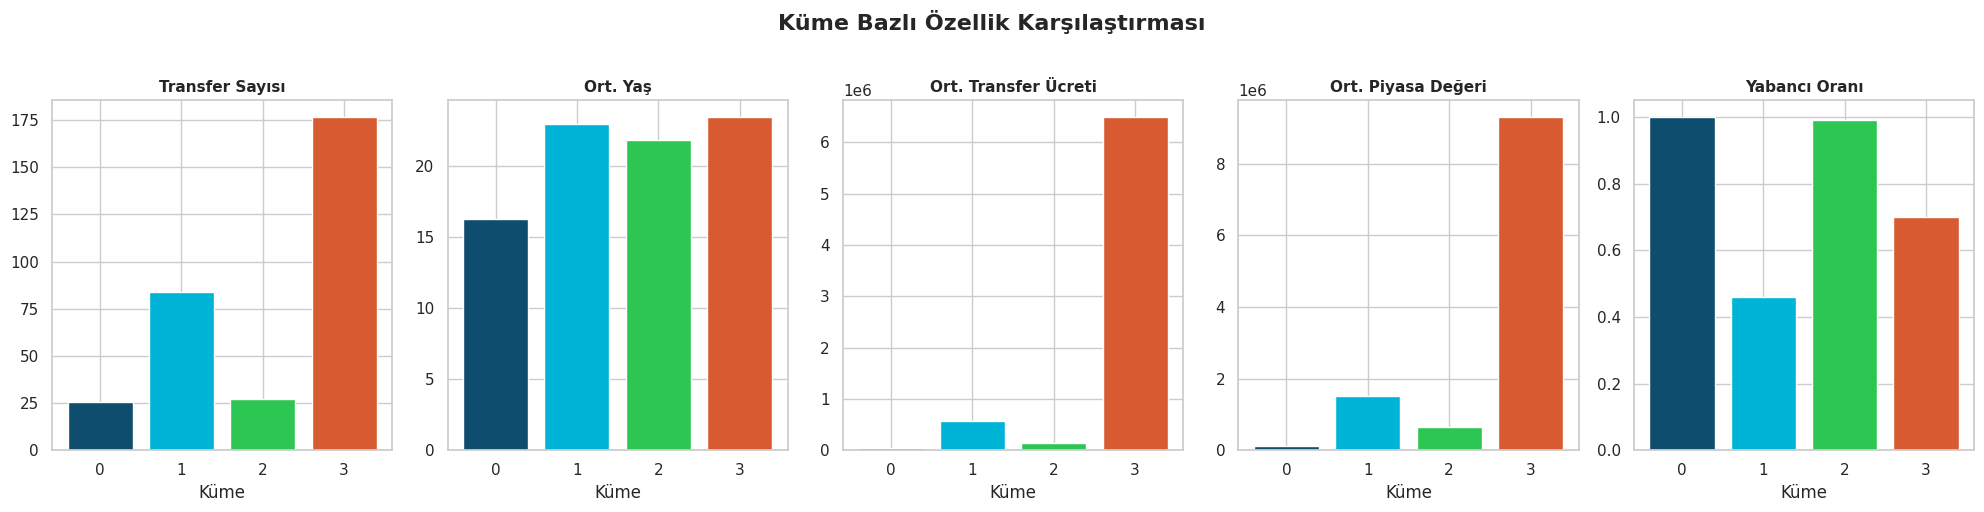

In [22]:
# Kume bazinda bar chart karsilastirma
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

feature_labels = [
    'Transfer Sayısı', 'Ort. Yaş', 'Ort. Transfer Ücreti',
    'Ort. Piyasa Değeri', 'Yabancı Oranı'
]
colors = ['#0E4D6E', '#00B4D8', '#2DC653', '#D85A30']

for idx, (feat, label) in enumerate(zip(features, feature_labels)):
    values = [cluster_profiles.loc[c, feat] for c in range(4)]
    bars = axes[idx].bar(range(4), values, color=colors, edgecolor='white')
    axes[idx].set_title(label, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Küme')
    axes[idx].set_xticks(range(4))

plt.suptitle('Küme Bazlı Özellik Karşılaştırması', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. PCA ile Görselleştirme

5 boyutlu veriyi 2 boyuta indirgeyelim ve kümeleri görselleştirelim.

PCA açıklanan varyans: 73.0%
  PC1: 50.9%
  PC2: 22.1%


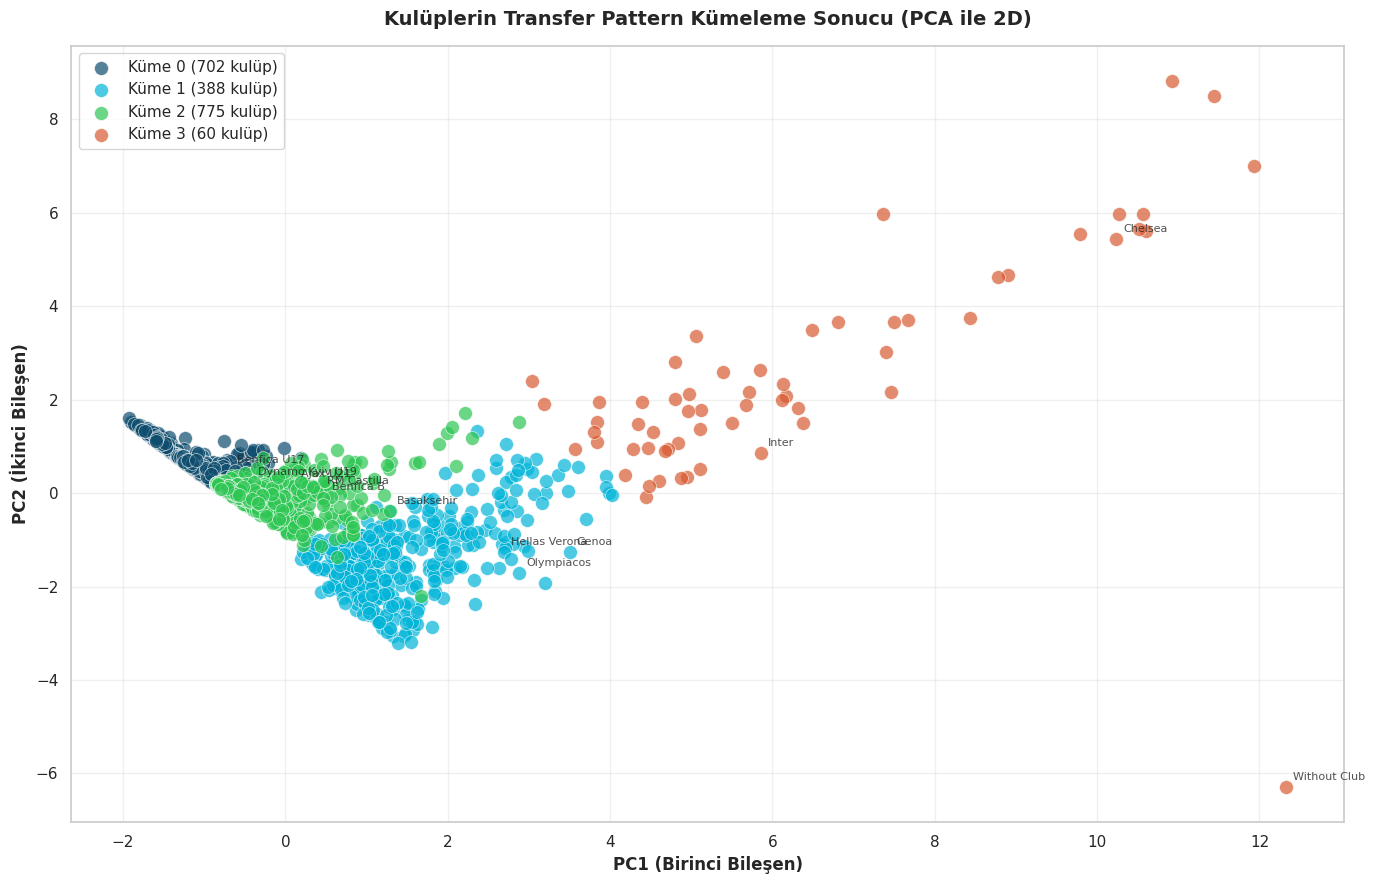

In [23]:
# PCA boyut indirgeme
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
club_summary['pca1'] = pca_result[:, 0]
club_summary['pca2'] = pca_result[:, 1]

print(f"PCA açıklanan varyans: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

# Gorsellestirme
plt.figure(figsize=(14, 9))
colors_map = {0: '#0E4D6E', 1: '#00B4D8', 2: '#2DC653', 3: '#D85A30'}

for cluster_id in sorted(club_summary['cluster'].unique()):
    mask = club_summary['cluster'] == cluster_id
    plt.scatter(
        club_summary.loc[mask, 'pca1'],
        club_summary.loc[mask, 'pca2'],
        c=colors_map[cluster_id],
        s=100, alpha=0.7, edgecolor='white', lw=0.5,
        label=f'Küme {cluster_id} ({mask.sum()} kulüp)'
    )

# Sadece her kumeden en belirgin 3 kulubu etiketle
for cluster_id in sorted(club_summary['cluster'].unique()):
    cluster_data = club_summary[club_summary['cluster'] == cluster_id]
    top_clubs = cluster_data.nlargest(3, 'transfer_count')
    for _, row in top_clubs.iterrows():
        plt.annotate(
            row['to_club_name'],
            xy=(row['pca1'], row['pca2']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=8, alpha=0.8
        )

plt.xlabel('PC1 (Birinci Bileşen)', fontsize=12, fontweight='bold')
plt.ylabel('PC2 (İkinci Bileşen)', fontsize=12, fontweight='bold')
plt.title('Kulüplerin Transfer Pattern Kümeleme Sonucu (PCA ile 2D)',
          fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Küme Bazlı Örnek Kulüpler

Her kümeden en çok transfer yapan kulüpleri listeleyelim.

In [24]:
# Her kumeden en cok transfer yapan 5 kulup
print("=" * 70)
print("  KÜME BAZLI EN AKTİF KULÜPLER")
print("=" * 70)

for cluster_id in sorted(club_summary['cluster'].unique()):
    cluster_data = club_summary[club_summary['cluster'] == cluster_id]
    top5 = cluster_data.nlargest(5, 'transfer_count')
    count = len(cluster_data)

    print(f"\n--- Küme {cluster_id} ({count} kulüp) ---")
    for _, row in top5.iterrows():
        print(f"  {row['to_club_name']:30s} | "
              f"Transfer: {row['transfer_count']:3.0f} | "
              f"Yaş: {row['avg_age']:.1f} | "
              f"Ücret: €{row['avg_transfer_fee']:>12,.0f} | "
              f"Yabancı: {row['foreign_ratio']*100:.0f}%")

  KÜME BAZLI EN AKTİF KULÜPLER

--- Küme 0 (702 kulüp) ---
  Ajax U21                       | Transfer: 136 | Yaş: 18.4 | Ücret: €     338,140 | Yabancı: 100%
  Benfica U17                    | Transfer: 119 | Yaş: 14.9 | Ücret: €           0 | Yabancı: 100%
  Dynamo Kyiv U19                | Transfer: 119 | Yaş: 16.9 | Ücret: €           0 | Yabancı: 100%
  Benfica U19                    | Transfer: 111 | Yaş: 16.7 | Ücret: €       7,692 | Yabancı: 100%
  Ajax Youth                     | Transfer: 110 | Yaş: 10.3 | Ücret: €       2,686 | Yabancı: 100%

--- Küme 1 (388 kulüp) ---
  Olympiacos                     | Transfer: 307 | Yaş: 23.4 | Ücret: €     474,751 | Yabancı: 58%
  Genoa                          | Transfer: 283 | Yaş: 23.3 | Ücret: €   1,128,846 | Yabancı: 51%
  Hellas Verona                  | Transfer: 263 | Yaş: 23.3 | Ücret: €     683,498 | Yabancı: 64%
  Shakhtar D.                    | Transfer: 252 | Yaş: 22.3 | Ücret: €   1,624,974 | Yabancı: 24%
  Dynamo Kyiv    

## 8. Sonuç ve Dışa Aktarma

---

In [25]:
# Sonuc ozeti
print("=" * 65)
print("  TRANSFER PATTERN ANALİZİ — ÖZET")
print("=" * 65)
print()
print(f"  Analiz edilen kulüp sayısı: {len(club_summary)}")
print(f"  Küme sayısı: 4 (Elbow Method)")
print(f"  PCA açıklanan varyans: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print()
print("  KÜME ÖZETLERİ:")
for c in range(4):
    p = cluster_profiles.loc[c]
    n = (club_summary['cluster'] == c).sum()
    print(f"    Küme {c} ({n} kulüp): Ort {p['transfer_count']:.0f} transfer, "
          f"€{p['avg_transfer_fee']:,.0f} ücret, {p['foreign_ratio']*100:.0f}% yabancı")
print()
print("=" * 65)

# CSV olarak kaydet
club_summary.to_csv("/content/club_transfer_clusters.csv", index=False)
print("\n✅ Sonuçlar 'club_transfer_clusters.csv' dosyasına kaydedildi.")

# Indirmek icin:
# from google.colab import files
# files.download("/content/club_transfer_clusters.csv")

  TRANSFER PATTERN ANALİZİ — ÖZET

  Analiz edilen kulüp sayısı: 1925
  Küme sayısı: 4 (Elbow Method)
  PCA açıklanan varyans: 73.0%

  KÜME ÖZETLERİ:
    Küme 0 (702 kulüp): Ort 26 transfer, €46,101 ücret, 100% yabancı
    Küme 1 (388 kulüp): Ort 84 transfer, €573,031 ücret, 46% yabancı
    Küme 2 (775 kulüp): Ort 27 transfer, €139,126 ücret, 99% yabancı
    Küme 3 (60 kulüp): Ort 177 transfer, €6,495,138 ücret, 70% yabancı


✅ Sonuçlar 'club_transfer_clusters.csv' dosyasına kaydedildi.
